In [479]:
# This cell imports the `warnings` module and configures it to suppress all warning messages
import warnings
warnings.filterwarnings("ignore")

In [480]:
# This cell installs essential Python libraries for biological data processing (Biopython), data manipulation (Pandas), and progress tracking (tqdm).
!pip install biopython pandas tqdm

In [481]:
# This cell imports various modules for making HTTP requests (requests), handling numerical operations (numpy)

import requests
import pandas as pd
import time
import re
import xml.etree.ElementTree as ET
import os

from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

In [482]:
#data analysis (pandas), time delays (time), and regular expressions (re). It also sets up a robust `requests` session with automatic retries for network resilience and disables insecure request warnings.

session = requests.Session()

retry = Retry(
    total=5,                     
    backoff_factor=1,           
    status_forcelist=[500, 502, 503, 504]
)

adapter = HTTPAdapter(max_retries=retry)
session.mount("https://", adapter)
session.mount("http://", adapter)

In [483]:
# This cell defines a list of specific disease names that will be used as search terms in the subsequent data retrieval process.
diseases = [
    "covid-19",
    "pneumonia",
    "tuberculosis",
    "lung cancer"
]

In [484]:
# This function constructs a formatted search query string for the PubMed database.
#It takes a disease name and combines it with terms like "case report" or "case series" to narrow down search results to relevant medical case studies
def build_query(disease):
    return f"({disease}) AND (\"case report\" OR \"case series\")"

In [485]:
# This function queries the NCBI E-utilities API to search the PubMed database using a given query. 
#It retrieves a specified maximum number of relevant article IDs (PIDs) in JSON format

def get_pubmed_ids(query, max_results=100):
    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"

    params = {
        "db": "pubmed",
        "term": query,
        "retmax": max_results,
        "retmode": "json"
    }

    response = session.get(url, params=params, timeout=30)
    data = response.json()

    return data["esearchresult"]["idlist"]

In [486]:

# Split IDs into batches to reduce requests

def chunk_ids(ids, size=10):
    for i in range(0, len(ids), size):
        yield ids[i:i + size]

In [487]:
# Fetch multiple abstracts in a single request

def fetch_abstracts_batch(id_list):
    ids_str = ",".join(map(str, id_list))

    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"

    params = {
        "db": "pubmed",
        "id": ids_str,
        "retmode": "xml"
    }

    try:
        response = session.get(url, params=params, timeout=30)
        return response.text
    except:
        return None

In [488]:
# ================================
# Parse XML response to extract abstract text
# ================================
def parse_abstracts(xml_data):
    results = []

    try:
        root = ET.fromstring(xml_data)
    except:
        return []

    articles = root.findall(".//PubmedArticle")

    for article in articles:
        # هات الـ ID
        pmid_elem = article.find(".//PMID")
        pmid = pmid_elem.text if pmid_elem is not None else None

        # هات الـ abstract
        abstract_text = ""
        abstract = article.find(".//Abstract")

        if abstract is not None:
            for text in abstract.findall("AbstractText"):
                if text.text:
                    abstract_text += text.text + " "

        results.append((pmid, abstract_text.strip()))

    return results

In [489]:
# This function determines if a given text (abstract) likely describes a valid medical case report or series.
#It does this by counting the occurrences of specific 'strong signal' keywords, indicating a clinical narrative.

def is_valid_case(text):
    text = text.lower()

    strong_signals = [
        "patient",
        "presents with",
        "admitted",
        "diagnosed",
        "case report",
        "symptoms"
    ]

    score = sum(1 for w in strong_signals if w in text)

    # لازم على الأقل 1  منهم يكون موجود علشان يكون ال extracted signals يكون من ضمن  
    return score >= 1

In [490]:
# This cell iterates through each defined disease, constructs a PubMed query, retrieves relevant article IDs, fetches their abstracts,
#and then filters these abstracts to keep only valid case reports, storing them in a `data` list
BATCH_SIZE = 10
data = []


for disease in diseases:
    query = build_query(disease)
    ids = get_pubmed_ids(query, 200)

    print(f"{disease} -> IDs fetched: {len(ids)}")

    for batch in chunk_ids(ids, BATCH_SIZE):
        xml_data = fetch_abstracts_batch(batch)

        if xml_data is None:
            continue

        parsed_data = parse_abstracts(xml_data)

        for pmid, abstract in parsed_data:
            if pmid and abstract and is_valid_case(abstract):
                data.append({
                    "disease": disease,
                    "pubmed_id": pmid,
                    "abstract": abstract
                })

        time.sleep(0.5)

print("Total collected:", len(data))

covid-19 -> IDs fetched: 200
pneumonia -> IDs fetched: 200
tuberculosis -> IDs fetched: 200
lung cancer -> IDs fetched: 200
Total collected: 602


In [491]:

df = pd.DataFrame(data)

print("Dataset shape:", df.shape)


Dataset shape: (602, 3)


In [492]:
# count no  of patients in each disease
df["disease"].value_counts()

disease
lung cancer     157
covid-19        153
tuberculosis    150
pneumonia       142
Name: count, dtype: int64

In [493]:
# This function attempts to extract a patient's age from a given text. It uses regular expressions to search for common patterns like "X-year-old" or "aged X" and returns the first numerical age found.

def extract_age(text):

    text = text.lower()

    patterns = [
        r"(\d{1,3})-year-old",
        r"aged (\d{1,3})",
        r"(\d{1,3}) years old"
    ]

    for p in patterns:

        match = re.search(p, text)

        if match:
            return int(match.group(1))

    return None

In [494]:
# This function identifies the gender of a patient from a given text. It searches for keywords such as "male," "man," "boy," "female," "woman," or "girl" and returns "male," "female," or "unknown" accordingly.

def extract_gender(text):

    text = text.lower()

    if re.search(r"\b(male|man|boy)\b", text):
        return "male"

    if re.search(r"\b(female|woman|girl)\b", text):
        return "female"

    return "unknown"

In [495]:
import re
import pandas as pd

# Medical symptom whitelist - كلمات شايعة في الأعراض
SYMPTOM_TERMS = {
    # respiratory
    "cough", "dyspnea", "shortness of breath", "wheezing", "hemoptysis",
    "respiratory distress", "tachypnea", "hypoxia", "chest pain", "chest tightness",
    "pleuritic pain", "stridor",
    # systemic
    "fever", "chills", "fatigue", "malaise", "weakness", "weight loss",
    "night sweats", "anorexia", "cachexia", "lethargy",
    # neurological
    "headache", "dizziness", "seizure", "confusion", "syncope",
    "altered consciousness", "altered mental status", "nausea", "vomiting",
    "diplopia", "vision loss", "blurred vision",
    # cardiovascular
    "palpitations", "edema", "tachycardia", "bradycardia", "hypotension",
    "hypertension", "chest discomfort",
    # GI
    "abdominal pain", "diarrhea", "constipation", "hematemesis", "melena",
    "jaundice", "bloating", "dysphagia",
    # musculoskeletal
    "myalgia", "arthralgia", "back pain", "joint pain", "muscle weakness",
    # skin
    "rash", "skin lesion", "erythema", "cyanosis", "pallor", "petechiae",
    "urticaria", "pruritus",
    # ENT
    "sore throat", "rhinorrhea", "nasal congestion", "otalgia", "epistaxis",
    "lymphadenopathy", "neck stiffness",
    # urinary
    "dysuria", "hematuria", "polyuria", "oliguria",
}

# كلمات نبعد عنها - مش symptoms
NON_SYMPTOM_PATTERNS = [
    r"^(patient|case|report|study|treatment|therapy|disease|condition|"
    r"hospital|diagnosis|history|years|month|week|day|male|female|woman|man|"
    r"child|adult|old|year|underwent|received|started|was|were|had|has|"
    r"following|due to|secondary|associated|underlying|known|previous|prior|"
    r"significant|notable|relevant|unremarkable|normal|abnormal|positive|negative|"
    r"admitted|presented|diagnosed|treated|managed|evaluated|referred|"
    r"underwent|performed|conducted|revealed|showed|demonstrated|indicated|"
    r"consistent|compatible|suggestive|consistent with|compatible with|"
    r"no significant|no history|no evidence|no known)s?$",
    r"\d+",        
    r"^\w{1,3}$",  
    r"^(a|an|the|and|or|but|with|for|from|this|that|these|those|it|its)$",
]

def clean_candidate(text):
    text = text.strip().lower()
    text = re.sub(r"[^a-zA-Z\s\-]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def is_valid_symptom(candidate):
    c = candidate.strip().lower()
    
    if len(c) < 4 or len(c) > 50:
        return False
    
    # لو في الـ whitelist مباشرة - قبول فوري
    if c in SYMPTOM_TERMS:
        return True
    
    # لو بيبدأ بـ verb نهايات - شبه أكيد مش symptom
    verb_endings = ("ing", "tion", "ment", "ance", "ence", "ness")
    known_ness = {"shortness", "tightness", "weakness", "dizziness", "hoarseness"}
    if c.endswith(("tion", "ment", "ance", "ence")) and c not in known_ness:
        return False
    
    # لو الـ candidate جملة طويلة (أكثر من 4 كلمات) - رفض
    words = c.split()
    if len(words) > 4:
        return False
    
    for pattern in NON_SYMPTOM_PATTERNS:
        if re.match(pattern, c, re.IGNORECASE):
            return False

    if len(words) == 1:
        if c.endswith("ed") and c not in {"altered", "decreased", "reduced"}:
            return False
    
    return True




In [496]:
def extract_symptoms_v2(text):
    """
    نسخة محسّنة من extract_symptoms:
    1. بتدور على الأعراض في الـ whitelist مباشرةً (أعلى دقة)
    2. بتستخدم regex patterns لكن بعدين بتفلتر النتايج بذكاء
    """
    if pd.isna(text):
        return []

    text_lower = text.lower()
    found_symptoms = set()

    # === Step 1: Direct whitelist matching (highest precision) ===
    for symptom in SYMPTOM_TERMS:
        if symptom in text_lower:
            found_symptoms.add(symptom)

    # === Step 2: Pattern-based extraction with smart filtering ===
    patterns = [
        r"presented with (.+?)[\.\.\;]",
        r"complained of (.+?)[\.\.\;]",
        r"symptoms included (.+?)[\.\.\;]",
        r"symptoms? of ([^.]+)",
        r"admitted with (.+?)[\.\.\;]",
        r"manifested (as|with) (.+?)[\.\.\;]",
        r"chief complaint[s]? (?:of|was|were|:) (.+?)[\.\.\;]",
        r"notable for (.+?)[\.\.\;]",
        r"including (.+?)[\.\.\;]",
    ]

    for pattern in patterns:
        matches = re.findall(pattern, text_lower)
        for match in matches:
            # لو tuple (من groups متعددة) خد الأخير
            if isinstance(match, tuple):
                match = match[-1]
            
            # قسّم على فواصل
            parts = re.split(r",|\band\b|;", match)
            
            for part in parts:
                candidate = clean_candidate(part)
                if is_valid_symptom(candidate):
                    found_symptoms.add(candidate)

    return sorted(list(found_symptoms))


In [497]:
# This cell applies the `extract_symptoms` function to each abstract in the DataFrame, creating a new column named 'symptoms'.
#It then filters the DataFrame to remove rows where no symptoms were successfully extracted, and finally displays the updated disease counts and the first 200 rows of the modified DataFrame.

df["symptoms"] = df["abstract"].apply(extract_symptoms_v2)
df = df[df["symptoms"].notnull()]
print(df["disease"].value_counts())


disease
lung cancer     157
covid-19        153
tuberculosis    150
pneumonia       142
Name: count, dtype: int64


In [498]:
# This cell applies the previously defined `extract_age`, `extract_gender`
#The results are stored in new 'age', 'gender'
df["age"] = df["abstract"].apply(extract_age)

df["gender"] = df["abstract"].apply(extract_gender)



In [499]:
# display as table 
df[[
    "disease",
    "age",
    "gender",
    "symptoms"
]].head(50)

,disease,age,gender,symptoms
0,covid-19,46.0,male,"[abdominal pain, fatigue, high ileostomy outpu..."
1,covid-19,NaN,unknown,[]
2,covid-19,NaN,unknown,[fever]
3,covid-19,NaN,unknown,[]
4,covid-19,NaN,unknown,"[bilious emesis, vomiting]"
5,covid-19,50.0,male,"[arterial thrombosis, cough, fever, resulting ..."
6,covid-19,59.0,male,[respiratory distress]
7,covid-19,18.0,unknown,[culture-positive pneumonia were identified]
8,covid-19,67.0,female,"[dysphagia, hypertension, resource limitations..."
9,covid-19,44.0,female,"[a sudden, confusion, dizziness, headache, pho..."


In [500]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   disease    602 non-null    object 
 1   pubmed_id  602 non-null    object 
 2   abstract   602 non-null    object 
 3   symptoms   602 non-null    object 
 4   age        387 non-null    float64
 5   gender     602 non-null    object 
dtypes: float64(1), object(5)
memory usage: 28.3+ KB


In [501]:
fake_null_mask = df.applymap(
    lambda x: str(x).strip() in ["[]", "()", "", "nan"]
)

print("Fake Nulls Count Per Column:\n")
print(fake_null_mask.sum())

Fake Nulls Count Per Column:

disease        0
pubmed_id      0
abstract       0
symptoms     200
age          215
gender         0
dtype: int64


In [502]:
df["disease"].unique()

array(['covid-19', 'pneumonia', 'tuberculosis', 'lung cancer'],
      dtype=object)

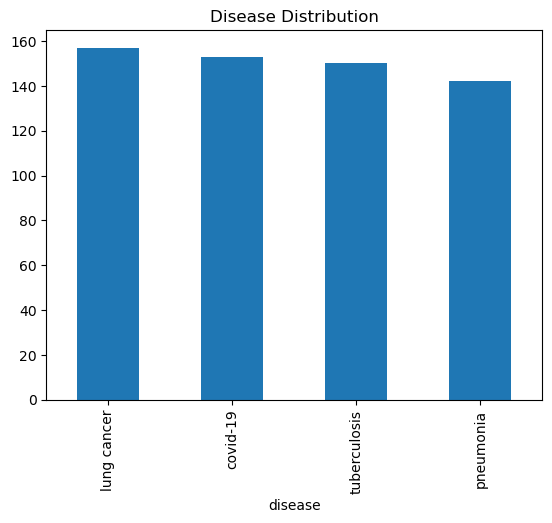

In [503]:
# Visualize class distribution to assess potential imbalance
import matplotlib.pyplot as plt
df["disease"].value_counts().plot(kind="bar", title="Disease Distribution")
plt.show()

In [504]:
drug_map = {

    "covid-19": [

        "remdesivir",
        "molnupiravir",
        "nirmatrelvir",
        "ritonavir",
        "dexamethasone",
        "tocilizumab"
    ],

    "pneumonia": [

        "amoxicillin",
        "azithromycin",
        "ceftriaxone",
        "levofloxacin",
        "doxycycline"
    ],

    "tuberculosis": [

        "isoniazid",
        "rifampicin",
        "pyrazinamide",
        "ethambutol",
        "streptomycin"
    ],

    "lung cancer": [

        "cisplatin",
        "carboplatin",
        "paclitaxel",
        "pembrolizumab",
        "etoposide",
        "gefitinib"
    ]
}

In [505]:
df["drugs"] = df["disease"].map(drug_map)

In [506]:
df[[
    "disease",
    "age",
    "gender",
    "symptoms",
    "drugs"
]].head(200)

,disease,age,gender,symptoms,drugs
0,covid-19,46.0,male,"[abdominal pain, fatigue, high ileostomy outpu...","[remdesivir, molnupiravir, nirmatrelvir, riton..."
1,covid-19,NaN,unknown,[],"[remdesivir, molnupiravir, nirmatrelvir, riton..."
2,covid-19,NaN,unknown,[fever],"[remdesivir, molnupiravir, nirmatrelvir, riton..."
3,covid-19,NaN,unknown,[],"[remdesivir, molnupiravir, nirmatrelvir, riton..."
4,covid-19,NaN,unknown,"[bilious emesis, vomiting]","[remdesivir, molnupiravir, nirmatrelvir, riton..."
...,...,...,...,...,...
195,pneumonia,59.0,male,"[altered mentationproductive coug, chills, fev...","[amoxicillin, azithromycin, ceftriaxone, levof..."
196,pneumonia,14.0,unknown,[],"[amoxicillin, azithromycin, ceftriaxone, levof..."
197,pneumonia,64.0,female,"[respiratory failure, septic shock]","[amoxicillin, azithromycin, ceftriaxone, levof..."
198,pneumonia,NaN,unknown,"[cough, wheezing]","[amoxicillin, azithromycin, ceftriaxone, levof..."


# Data Cleaning




In [507]:
df.shape

(602, 7)

In [508]:
fake_null_mask = df.applymap(
    lambda x: str(x).strip() in ["[]", "()", "", "nan"]
)

print("Fake Nulls Count Per Column:\n")
print(fake_null_mask.sum())

Fake Nulls Count Per Column:

disease        0
pubmed_id      0
abstract       0
symptoms     200
age          215
gender         0
drugs          0
dtype: int64


In [525]:
missing_by_disease = df.groupby('disease')['symptoms'] \
    .apply(lambda x: (x.apply(lambda y: y == []).sum()))

print(missing_by_disease.sort_values(ascending=False))

disease
covid-19        0
lung cancer     0
pneumonia       0
tuberculosis    0
Name: symptoms, dtype: int64


In [509]:
# Detect statistical outliers using IQR

Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["age"] < lower_bound) | (df["age"] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", outliers.shape[0])

Lower bound: -20.5
Upper bound: 119.5
Number of outliers: 0


In [510]:
df["age"] = df["age"].fillna(df["age"].mean())

In [511]:
df['age'].isnull().sum()

0

In [512]:
print("\nDisease distribution:\n", df["disease"].value_counts())


Disease distribution:
 disease
lung cancer     157
covid-19        153
tuberculosis    150
pneumonia       142
Name: count, dtype: int64


In [513]:
df.shape

(602, 7)

In [514]:
import ast
df_exploded = df.explode('symptoms')
df_exploded.groupby(['disease', 'symptoms']).size().sort_values(ascending=False)

disease       symptoms                     
tuberculosis  fever                            37
pneumonia     fever                            36
              cough                            30
covid-19      fever                            27
pneumonia     dyspnea                          23
                                               ..
lung cancer   including liver                   1
              individuals of asian ancestry     1
              interstitial lung disease ild     1
              intractable cough                 1
tuberculosis  worsening pain                    1
Length: 787, dtype: int64

In [515]:
top_symptoms = (
    df_exploded.groupby('disease')['symptoms']
    .apply(lambda x: x.value_counts().head(5).index.tolist())
)

In [516]:
top_symptoms_df = top_symptoms.reset_index()
top_symptoms_df.columns = ['disease', 'top5 symptoms']

print(top_symptoms_df)

        disease                                      top5 symptoms
0      covid-19         [fever, fatigue, cough, weakness, dyspnea]
1   lung cancer   [fever, dyspnea, cough, weight loss, hemoptysis]
2     pneumonia  [fever, cough, dyspnea, respiratory distress, ...
3  tuberculosis  [fever, cough, weight loss, abdominal pain, dy...


In [517]:
fake_null_mask = df.applymap(
    lambda x: str(x).strip() in ["[]", "()", "", "nan"]
)
print(fake_null_mask.sum())

disease        0
pubmed_id      0
abstract       0
symptoms     200
age            0
gender         0
drugs          0
dtype: int64


In [518]:
import numpy as np

def fill_missing_symptoms(row):
    s = row['symptoms']

    # لو مش list أو list فاضية
    if not isinstance(s, list) or len(s) == 0:
        return top_symptoms.get(row['disease'], [])

    return s

In [519]:
df['symptoms'] = df.apply(fill_missing_symptoms, axis=1)

In [520]:
fake_null_mask = df.applymap(
    lambda x: str(x).strip() in ["[]", "()", "", "nan"]
)
print(fake_null_mask.sum())

disease      0
pubmed_id    0
abstract     0
symptoms     0
age          0
gender       0
drugs        0
dtype: int64


In [522]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   disease    602 non-null    object 
 1   pubmed_id  602 non-null    object 
 2   abstract   602 non-null    object 
 3   symptoms   602 non-null    object 
 4   age        602 non-null    float64
 5   gender     602 non-null    object 
 6   drugs      602 non-null    object 
dtypes: float64(1), object(6)
memory usage: 33.1+ KB


In [524]:
df['age'] = df['age'].astype(int)
df.head(20)

,disease,pubmed_id,abstract,symptoms,age,gender,drugs
0,covid-19,42066025,BACKGROUND The coronavirus disease 2019 (COVID...,"[abdominal pain, fatigue, high ileostomy outpu...",46,male,"[remdesivir, molnupiravir, nirmatrelvir, riton..."
1,covid-19,42064712,Coronavirus Disease 2019 (COVID-19) primarily ...,"[fever, fatigue, cough, weakness, dyspnea]",49,unknown,"[remdesivir, molnupiravir, nirmatrelvir, riton..."
2,covid-19,42061500,Acute limb ischemia (ALI) is a severe complica...,[fever],49,unknown,"[remdesivir, molnupiravir, nirmatrelvir, riton..."
3,covid-19,42047448,Despite the potential association between Kawa...,"[fever, fatigue, cough, weakness, dyspnea]",49,unknown,"[remdesivir, molnupiravir, nirmatrelvir, riton..."
4,covid-19,42046584,COVID-19 can present with gastrointestinal sym...,"[bilious emesis, vomiting]",49,unknown,"[remdesivir, molnupiravir, nirmatrelvir, riton..."
5,covid-19,42040548,This case report describes a 50-year-old man w...,"[arterial thrombosis, cough, fever, resulting ...",50,male,"[remdesivir, molnupiravir, nirmatrelvir, riton..."
6,covid-19,42037642,Midline peripheral intravenous catheters are w...,[respiratory distress],59,male,"[remdesivir, molnupiravir, nirmatrelvir, riton..."
7,covid-19,42036116,"We hypothesized that the incidence, clinical p...",[culture-positive pneumonia were identified],18,unknown,"[remdesivir, molnupiravir, nirmatrelvir, riton..."
8,covid-19,42028544,"Chagasic esophagopathy, resulting from Trypano...","[dysphagia, hypertension, resource limitations...",67,female,"[remdesivir, molnupiravir, nirmatrelvir, riton..."
9,covid-19,42027389,Reversible cerebral vasoconstriction syndrome ...,"[a sudden, confusion, dizziness, headache, pho...",44,female,"[remdesivir, molnupiravir, nirmatrelvir, riton..."


In [526]:
#check text befor filtering
before_filtering = df.shape[0]
# Text Cleaning Pipeline for Abstract Column

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Text Cleaning Pipeline for Abstract Column
    text = text.lower()
   #  Removing URLs and external links
    text = re.sub(r"http\S+", "", text)

    #  Eliminating noise such as special characters
    text = re.sub(r"[^\w\s.,-]", "", text)

    #  Reducing multiple spaces to a single space
    text = re.sub(r"\s+", " ", text)
    return text.strip()
df["abstract"] = df["abstract"].apply(clean_text)
after_filtering = df.shape[0]
print("Rows removed:", before_filtering - after_filtering)

Rows removed: 0


In [528]:
df.shape

(602, 7)